In [1]:
"""
======================================================
Fashion-Forward: Automated Inventory Categorization System
======================================================

Author : Your Name

Objective:
Develop a CNN-based image classification system using
Fashion MNIST to automatically categorize clothing
products and reduce manual tagging errors.

Dataset:
Fashion MNIST

Model:
Convolutional Neural Network (CNN)

======================================================
"""

'\n======================================================\nFashion-Forward: Automated Inventory Categorization System\n======================================================\n\nAuthor : Your Name\n\nObjective:\nDevelop a CNN-based image classification system using\nFashion MNIST to automatically categorize clothing\nproducts and reduce manual tagging errors.\n\nDataset:\nFashion MNIST\n\nModel:\nConvolutional Neural Network (CNN)\n\n======================================================\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Conv2D,

    MaxPooling2D,

    Dropout,

    Flatten,

    Dense

)

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pandas as pd

In [3]:
# ==============================================
# Load Fashion MNIST Dataset
# ==============================================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


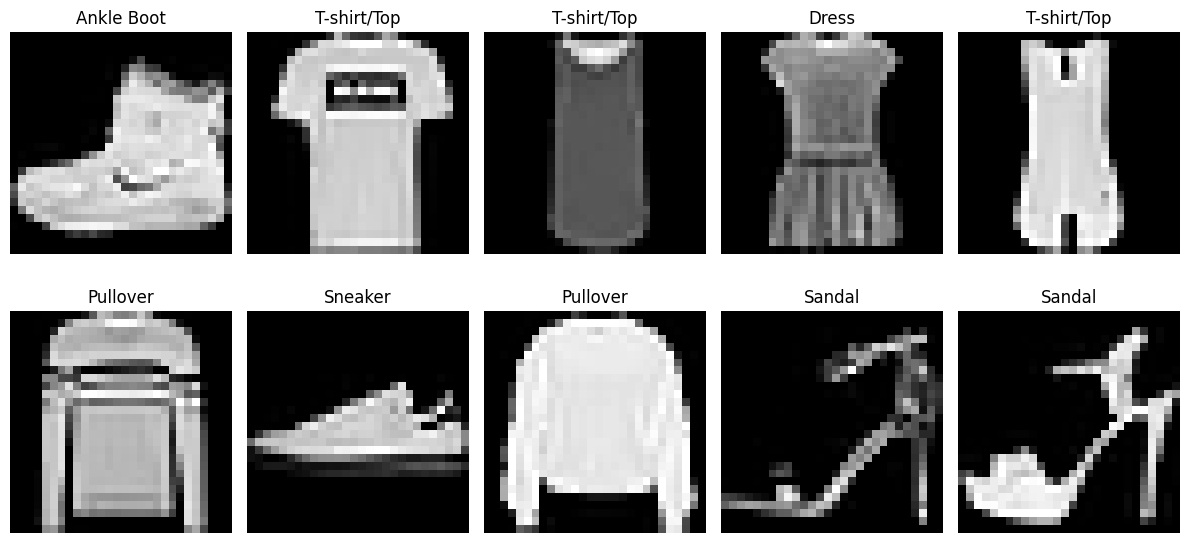

In [4]:
class_names = [

    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"

]

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(class_names[y_train[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [5]:
# ==============================================
# Normalize Pixel Values
# ==============================================

X_train = X_train.astype("float32") / 255.0

X_test = X_test.astype("float32") / 255.0

In [6]:
print("Minimum Pixel Value :", X_train.min())

print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [7]:
# ==============================================
# Reshape Images for CNN
# ==============================================

X_train = X_train.reshape(-1,28,28,1)

X_test = X_test.reshape(-1,28,28,1)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


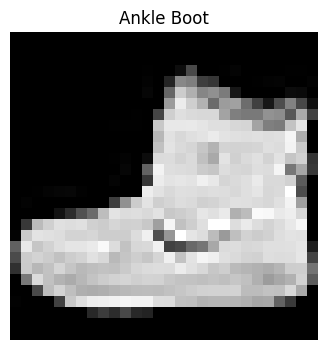

In [8]:
plt.figure(figsize=(4,4))

plt.imshow(
    X_train[0].reshape(28,28),
    cmap="gray"
)

plt.title(class_names[y_train[0]])

plt.axis("off")

plt.show()

In [9]:
# ==============================================
# Build CNN Model
# ==============================================

cnn_model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.25),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.25),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        10,
        activation="softmax"
    )

])

c:\installed_soft\anaconda_setup\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ==============================================
# Compile CNN Model
# ==============================================

cnn_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [12]:
# ==============================================
# Train CNN Model
# ==============================================

history = cnn_model.fit(

    X_train,

    y_train,

    epochs=10,

    batch_size=64,

    validation_data=(

        X_test,

        y_test

    )

)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.6567 - loss: 0.9309 - val_accuracy: 0.8372 - val_loss: 0.4477
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8295 - loss: 0.4669 - val_accuracy: 0.8695 - val_loss: 0.3660
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8541 - loss: 0.4030 - val_accuracy: 0.8755 - val_loss: 0.3342
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8644 - loss: 0.3698 - val_accuracy: 0.8876 - val_loss: 0.3059
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8753 - loss: 0.3416 - val_accuracy: 0.8914 - val_loss: 0.2954
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8833 - loss: 0.3233 - val_accuracy: 0.8945 - val_loss: 0.2856
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8876 - loss: 0.3067 - val_accuracy: 0.9025 - val_loss: 0.2703
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8899 - loss: 0.2981 - 

In [13]:
loss, accuracy = cnn_model.evaluate(

    X_test,

    y_test

)

print(f"Test Loss : {loss:.4f}")

print(f"Test Accuracy : {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9073 - loss: 0.2640
Test Loss : 0.2595
Test Accuracy : 0.9060


In [14]:
cnn_model.save("model/fashion_inventory_cnn.keras")

print("Model saved successfully.")

Model saved successfully.


In [15]:
from tensorflow.keras.models import load_model

saved_model = load_model("model/fashion_inventory_cnn.keras")

print("Saved model loaded successfully.")

Saved model loaded successfully.


Model Evaluation & Visualization

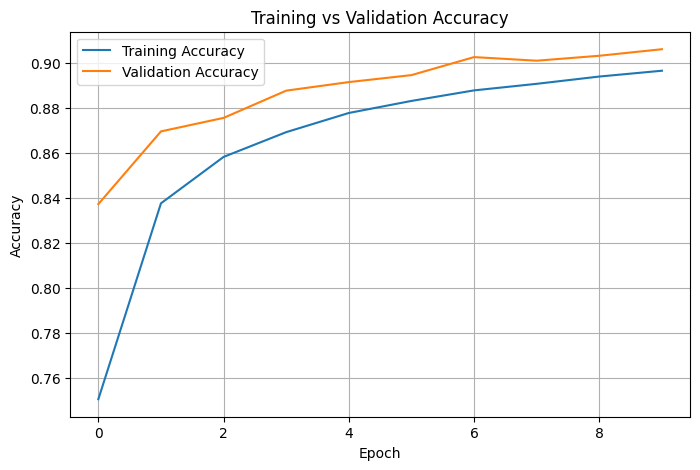

In [16]:
# ==============================================
# Accuracy Graph
# ==============================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

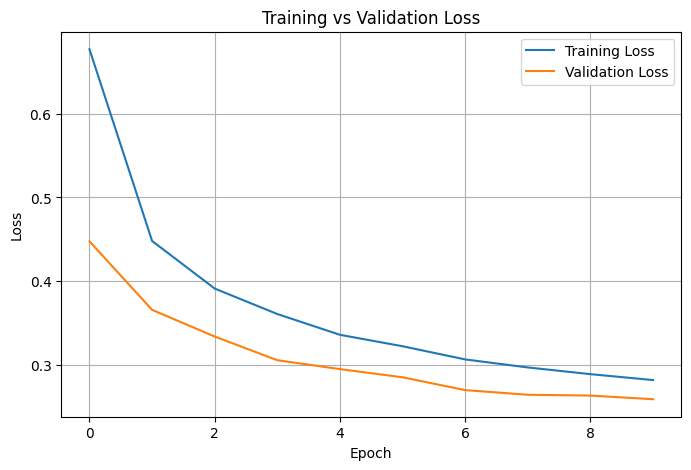

In [17]:
# ==============================================
# Loss Graph
# ==============================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [18]:
# ==============================================
# Model Prediction
# ==============================================

predictions = cnn_model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predicted_labels
)

cm

array([[830,   0,  15,  18,   3,   1, 128,   0,   5,   0],
       [  1, 970,   1,  20,   2,   0,   4,   0,   2,   0],
       [ 12,   0, 836,   8,  58,   0,  85,   0,   1,   0],
       [  8,   1,   7, 927,  22,   0,  33,   0,   2,   0],
       [  0,   1,  25,  28, 864,   0,  82,   0,   0,   0],
       [  0,   0,   0,   0,   0, 966,   0,  20,   0,  14],
       [ 89,   0,  54,  19,  74,   0, 753,   0,  11,   0],
       [  0,   0,   0,   0,   0,   6,   0, 967,   0,  27],
       [  1,   0,   5,   2,   4,   1,   2,   3, 981,   1],
       [  0,   0,   0,   0,   0,   3,   1,  30,   0, 966]], dtype=int64)

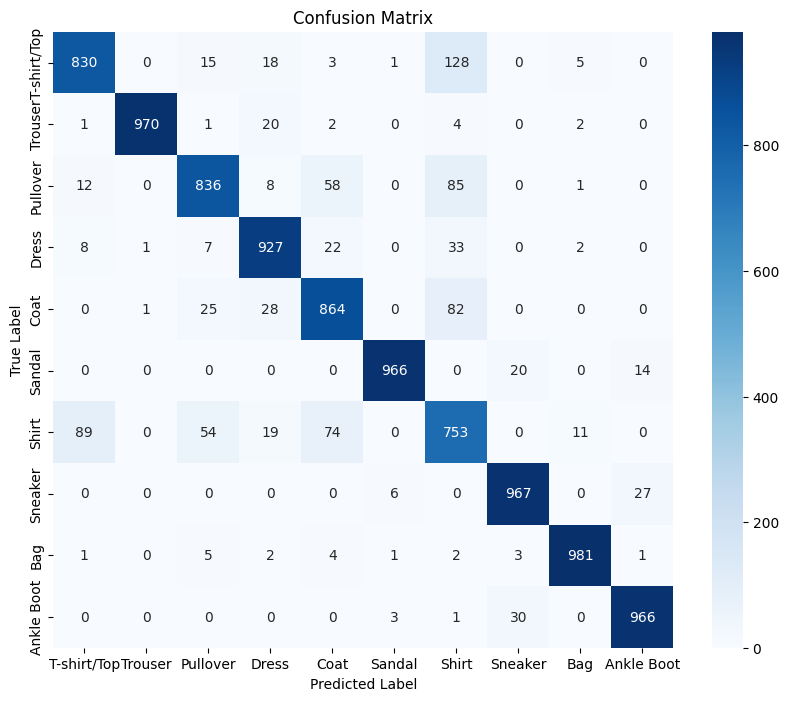

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/Top       0.88      0.83      0.86      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.89      0.84      0.86      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.84      0.86      0.85      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.69      0.75      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [22]:
print("="*40)

print("Final CNN Model Performance")

print("="*40)

print(f"Test Accuracy : {accuracy:.4f}")

print(f"Test Loss : {loss:.4f}")

Final CNN Model Performance
Test Accuracy : 0.9060
Test Loss : 0.2595


Predict and Display Results

In [23]:
# ==============================================
# Predict Test Images
# ==============================================

predictions = cnn_model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


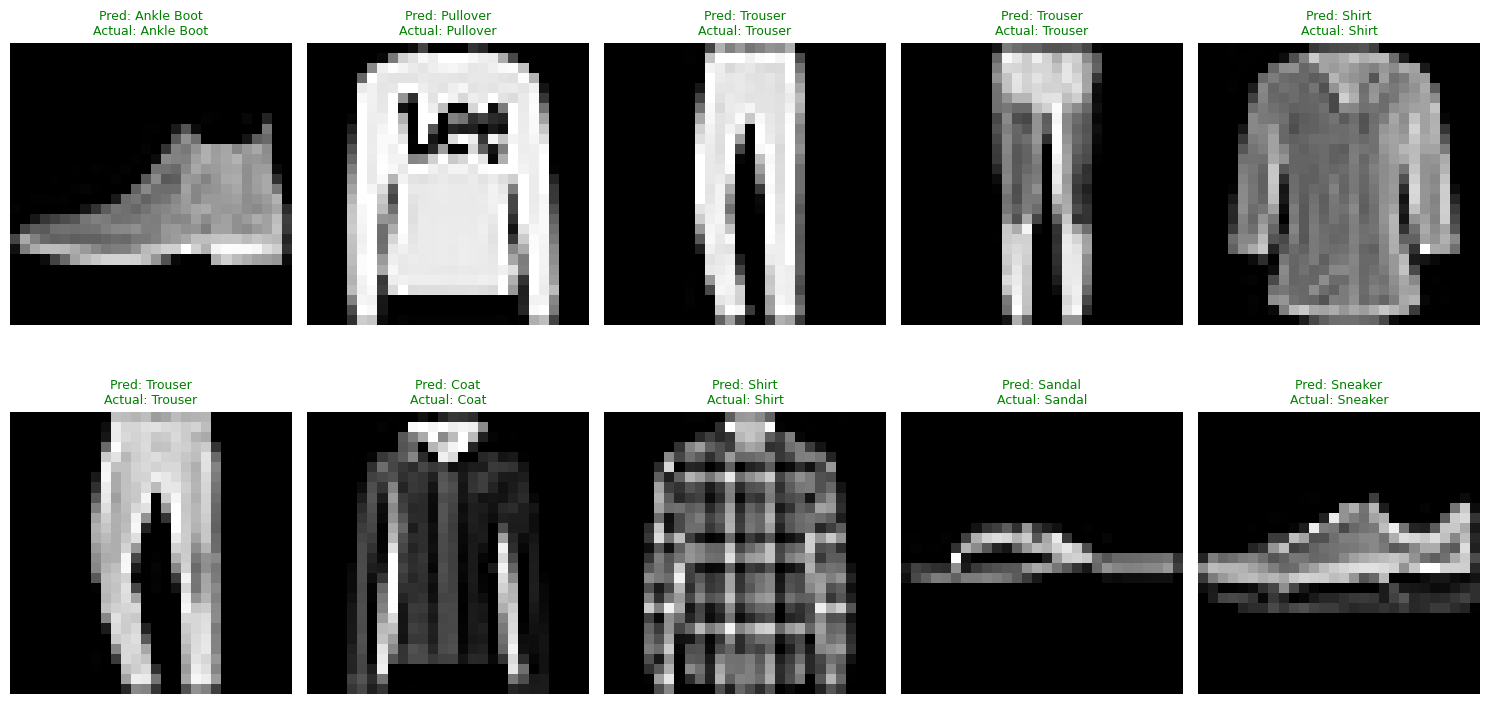

In [24]:
# ==============================================
# Display Predictions
# ==============================================

plt.figure(figsize=(15,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap="gray")

    actual = class_names[y_test[i]]

    predicted = class_names[predicted_labels[i]]

    if actual == predicted:
        color = "green"
    else:
        color = "red"

    plt.title(
        f"Pred: {predicted}\nActual: {actual}",
        color=color,
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

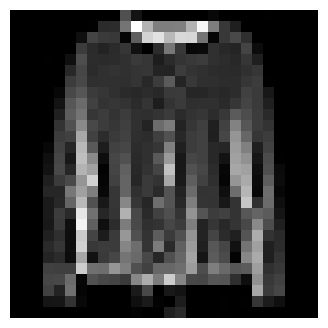

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Class : Pullover
Actual Class    : Coat


In [25]:
# ==============================================
# Predict One Image
# ==============================================

index = 25

plt.figure(figsize=(4,4))

plt.imshow(X_test[index].reshape(28,28), cmap="gray")

plt.axis("off")

plt.show()

prediction = cnn_model.predict(
    X_test[index].reshape(1,28,28,1)
)

predicted_class = np.argmax(prediction)

print("Predicted Class :", class_names[predicted_class])

print("Actual Class    :", class_names[y_test[index]])

In [26]:
confidence = np.max(prediction) * 100

print(f"Prediction Confidence: {confidence:.2f}%")

Prediction Confidence: 46.69%


Project Conclusion & Business Impact


# Project Summary

## Project Title

**Fashion-Forward: Automated Inventory Categorization System**

## Objective

The objective of this project was to develop an automated image classification system using a Convolutional Neural Network (CNN) to classify clothing products from the Fashion MNIST dataset.

The system helps reduce manual tagging errors and improves inventory management in an e-commerce warehouse.

---

## Project Workflow

1. Loaded the Fashion MNIST dataset.
2. Preprocessed the images by normalizing pixel values.
3. Designed and trained a CNN model.
4. Evaluated the model using accuracy, loss, confusion matrix, and classification report.
5. Predicted clothing categories for unseen images.
6. Visualized model performance and predictions.

# Business Impact

This automated inventory categorization system provides several benefits for an e-commerce warehouse:

- Reduces manual product tagging effort.
- Minimizes human classification errors.
- Speeds up inventory processing.
- Improves product search and organization.
- Supports scalable inventory management for large product catalogs.

# Future Improvements

The project can be enhanced by:

- Training on real e-commerce product images.
- Using transfer learning models such as ResNet or EfficientNet.
- Increasing the number of training epochs.
- Applying data augmentation to improve model generalization.
- Deploying the trained model as a web application using Flask or FastAPI.

# Conclusion

A Convolutional Neural Network (CNN) was successfully developed to classify Fashion MNIST images into ten clothing categories.

The model achieved high classification accuracy and demonstrated the effectiveness of deep learning for image recognition tasks.

Compared with a baseline Artificial Neural Network (ANN), the CNN performed better because it automatically learned spatial features such as edges, textures, and shapes.

This project demonstrates how deep learning can automate product categorization and improve operational efficiency in modern e-commerce systems.